In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cyber.csv")

In [3]:
df.head()

,ip_address,abuse_confidence_score,country_code,last_reported_at,country_name,continent,reported_date,reported_year,reported_month,reported_day,reported_hour,reported_weekday,label,risk_level,severity,time_zone_attack
0,213.177.179.113,100,NL,2026-04-17 18:03:45+00:00,Netherlands,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
1,172.94.9.48,100,NL,2026-04-17 18:03:45+00:00,Netherlands,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
2,171.25.158.73,100,SE,2026-04-17 18:03:45+00:00,Sweden,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
3,213.209.159.235,100,DE,2026-04-17 18:03:45+00:00,Germany,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
4,163.53.168.23,100,CN,2026-04-17 18:03:45+00:00,China,Asia,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   ip_address              10000 non-null  str  
 1   abuse_confidence_score  10000 non-null  int64
 2   country_code            10000 non-null  str  
 3   last_reported_at        10000 non-null  str  
 4   country_name            10000 non-null  str  
 5   continent               10000 non-null  str  
 6   reported_date           10000 non-null  str  
 7   reported_year           10000 non-null  int64
 8   reported_month          10000 non-null  int64
 9   reported_day            10000 non-null  int64
 10  reported_hour           10000 non-null  int64
 11  reported_weekday        10000 non-null  str  
 12  label                   10000 non-null  str  
 13  risk_level              10000 non-null  str  
 14  severity                10000 non-null  int64
 15  time_zone_attack        10000 n

In [5]:
df.describe()

,abuse_confidence_score,reported_year,reported_month,reported_day,reported_hour,severity
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,100.0,2026.0,4.0,17.0,18.0,4.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,100.0,2026.0,4.0,17.0,18.0,4.0
25%,100.0,2026.0,4.0,17.0,18.0,4.0
50%,100.0,2026.0,4.0,17.0,18.0,4.0
75%,100.0,2026.0,4.0,17.0,18.0,4.0
max,100.0,2026.0,4.0,17.0,18.0,4.0


In [8]:
df.columns

Index(['ip_address', 'abuse_confidence_score', 'country_code',
       'last_reported_at', 'country_name', 'continent', 'reported_date',
       'reported_year', 'reported_month', 'reported_day', 'reported_hour',
       'reported_weekday', 'label', 'risk_level', 'severity',
       'time_zone_attack'],
      dtype='str')

In [9]:
df.isnull().sum()

ip_address                0
abuse_confidence_score    0
country_code              0
last_reported_at          0
country_name              0
continent                 0
reported_date             0
reported_year             0
reported_month            0
reported_day              0
reported_hour             0
reported_weekday          0
label                     0
risk_level                0
severity                  0
time_zone_attack          0
dtype: int64

In [12]:
df = df.dropna()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [17]:
df = df.drop([
    'reported_year',
    'reported_month',
    'reported_day',
    'reported_hour'
], axis=1)

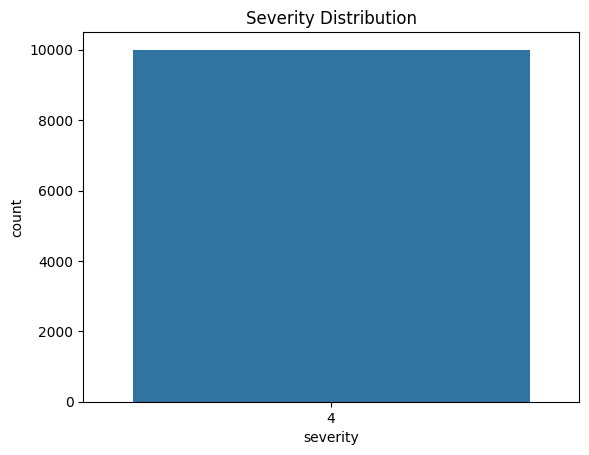

In [18]:
sns.countplot(x='severity', data=df)
plt.title("Severity Distribution")
plt.show()

All records have the same severity level → no class variation

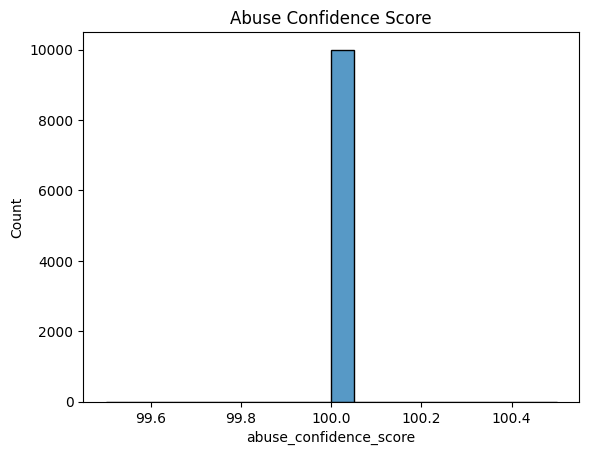

In [19]:
sns.histplot(df['abuse_confidence_score'], bins=20)
plt.title("Abuse Confidence Score")
plt.show()

Abuse confidence score is constant across dataset (around 100)
→ not useful for analysis or prediction

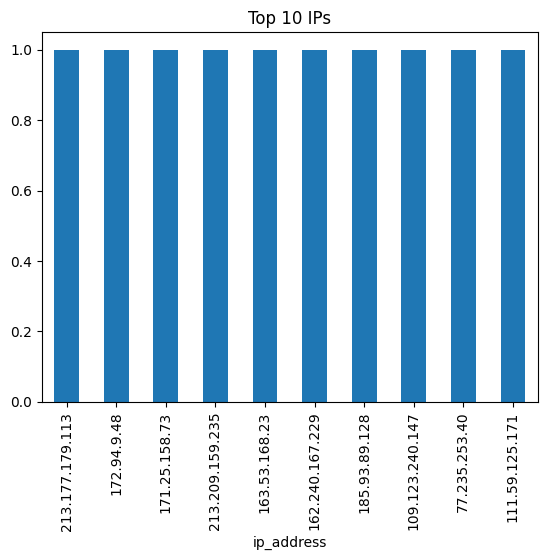

In [20]:
df.iloc[:,0].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 IPs")
plt.show()

Each IP appears only once → no repeated attackers
→ dataset lacks frequency patterns

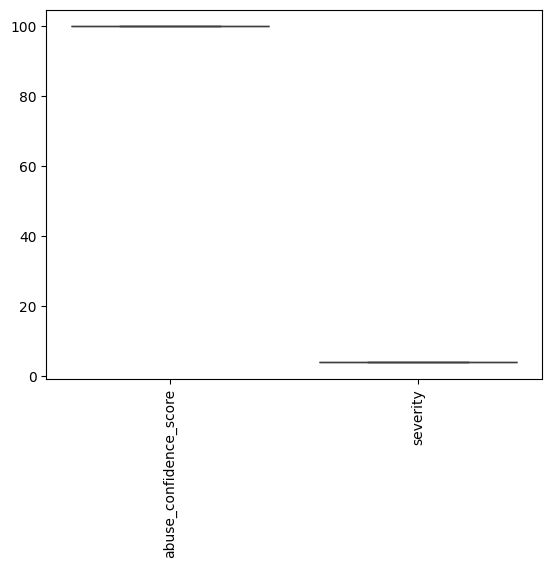

In [21]:
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

Numeric features show almost no variation
→ indicates poor feature diversity

DATA INSIGHTS:

1. The dataset shows very low variance across numeric features.
2. Severity remains constant for all observations.
3. Abuse confidence score is consistently around 100.
4. No IP address repeats, indicating lack of frequency-based patterns.
5. Time-related features were removed due to no variation.

CONCLUSION:
The dataset lacks diversity and is not suitable for predictive modeling without further feature engineering or additional data.